# Nodo Sensor IoT — Monitoreo Ergonómico
## Actividad 2: Adquisición y registro de datos

**Proyecto:** Sistema IoT para el monitoreo ergonómico en tiempo real  
**Integrantes:** Mario Esteban Vargas Pisco · Yeison Esteven García Olaya  
**Curso:** Internet de las Cosas — Universidad de La Salle · 2026-1  

---

### Descripción
Este notebook simula el comportamiento del nodo sensor implementado en Wokwi,
generando 360 registros durante un periodo de 3 horas con intervalos de 30 segundos.
Las variables monitoreadas son:
- **Ángulo de inclinación del tronco** (MPU-6050 simulado)
- **Presión en el asiento** (FSR402 simulado)

In [1]:
# Librerías necesarias
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("✅ Librerías cargadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

✅ Librerías cargadas correctamente
   pandas  2.2.3
   numpy   1.26.4


## Parámetros de la simulación

| Parámetro | Valor |
|---|---|
| Duración total | 3 horas |
| Intervalo de muestreo | 30 segundos |
| Total de registros | 360 |
| Inicio de jornada | 08:00:00 |
| Fin de jornada | 11:00:00 |
| Umbral ángulo inadecuado | > 20° |
| Umbral presión ocupado | > 200 |
| Umbral pausa activa | > 50 minutos continuos |

In [2]:
# ── Parámetros de la simulación ─────────────────────────
DURACION_HORAS   = 3
INTERVALO_SEG    = 30
TOTAL_REGISTROS  = int((DURACION_HORAS * 3600) / INTERVALO_SEG)
INICIO_JORNADA   = datetime(2026, 5, 3, 8, 0, 0)
UMBRAL_PRESION   = 200
UMBRAL_ANGULO    = 20.0
UMBRAL_PAUSA     = 50  # minutos

print(f"Total de registros a generar: {TOTAL_REGISTROS}")

Total de registros a generar: 360


In [3]:
# ── Simulador de sensores ────────────────────────────────
np.random.seed(42)  # reproducibilidad

def simular_jornada(total_registros, inicio):
    registros = []
    tiempo_sentado = 0.0
    
    for i in range(total_registros):
        timestamp = inicio + timedelta(seconds=i * INTERVALO_SEG)
        
        # Simular presión (FSR402)
        # 80% del tiempo el trabajador está sentado
        ocupado = np.random.random() > 0.20
        presion = np.random.randint(800, 4095) if ocupado else np.random.randint(0, 150)
        
        # Simular ángulo (MPU-6050)
        # Postura varía entre correcta e inadecuada
        if ocupado:
            angulo = np.random.normal(loc=15, scale=12)
            angulo = round(max(-30, min(60, angulo)), 1)
        else:
            angulo = round(np.random.normal(loc=0, scale=5), 1)
        
        # Acumular tiempo sentado
        if ocupado:
            tiempo_sentado += INTERVALO_SEG / 60
        else:
            tiempo_sentado = 0.0
        
        registros.append({
            "timestamp":      timestamp.strftime("%Y-%m-%d %H:%M:%S"),
            "angulo_grados":  angulo,
            "presion_adc":    int(presion),
            "ocupado":        "SI" if ocupado else "NO",
            "tiempo_sentado": round(tiempo_sentado, 1)
        })
    
    return pd.DataFrame(registros)

# Generar datos
df = simular_jornada(TOTAL_REGISTROS, INICIO_JORNADA)
print(f"✅ Simulación completada: {len(df)} registros generados")
print(f"   Desde: {df['timestamp'].iloc[0]}")
print(f"   Hasta: {df['timestamp'].iloc[-1]}")

✅ Simulación completada: 360 registros generados
   Desde: 2026-05-03 08:00:00
   Hasta: 2026-05-03 10:59:30


In [4]:
# ── Vista previa de los datos ────────────────────────────
print("=== PRIMEROS 5 REGISTROS ===")
display(df.head())

print("\n=== ÚLTIMOS 5 REGISTROS ===")
display(df.tail())

print(f"\n=== RESUMEN ===")
print(f"Total registros:      {len(df)}")
print(f"Registros ocupado SI: {len(df[df['ocupado'] == 'SI'])}")
print(f"Registros ocupado NO: {len(df[df['ocupado'] == 'NO'])}")
print(f"Ángulo promedio:      {df['angulo_grados'].mean():.1f}°")
print(f"Ángulo máximo:        {df['angulo_grados'].max():.1f}°")
print(f"Tiempo sentado máx:   {df['tiempo_sentado'].max():.1f} min")

=== PRIMEROS 5 REGISTROS ===


,timestamp,angulo_grados,presion_adc,ocupado,tiempo_sentado
0,2026-05-03 08:00:00,21.5,1660,SI,0.5
1,2026-05-03 08:00:30,7.6,2969,SI,1.0
2,2026-05-03 08:01:00,-10.1,74,NO,0.0
3,2026-05-03 08:01:30,-2.5,130,NO,0.0
4,2026-05-03 08:02:00,1.2,1,NO,0.0



=== ÚLTIMOS 5 REGISTROS ===


,timestamp,angulo_grados,presion_adc,ocupado,tiempo_sentado
355,2026-05-03 10:57:30,30.3,1163,SI,0.5
356,2026-05-03 10:58:00,39.5,3344,SI,1.0
357,2026-05-03 10:58:30,20.8,4032,SI,1.5
358,2026-05-03 10:59:00,12.4,2249,SI,2.0
359,2026-05-03 10:59:30,27.0,1345,SI,2.5



=== RESUMEN ===
Total registros:      360
Registros ocupado SI: 281
Registros ocupado NO: 79
Ángulo promedio:      11.4°
Ángulo máximo:        51.7°
Tiempo sentado máx:   6.0 min


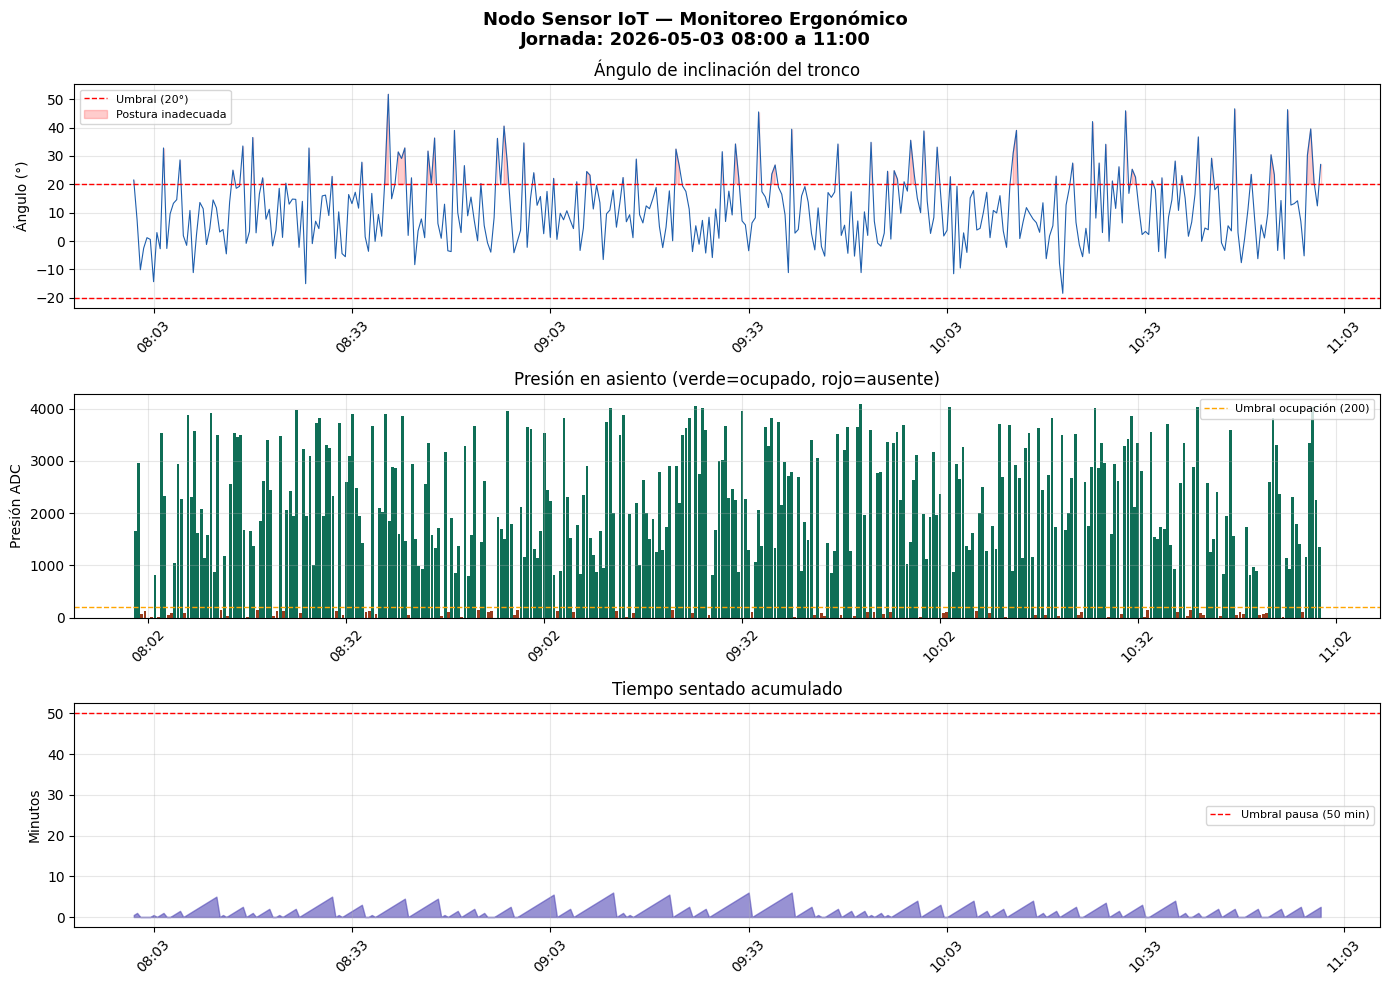

✅ Gráfica guardada en Datos/graficas_jornada.png


In [5]:
# ── Visualización de datos ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Nodo Sensor IoT — Monitoreo Ergonómico\nJornada: 2026-05-03 08:00 a 11:00", 
             fontsize=13, fontweight='bold')

timestamps = pd.to_datetime(df['timestamp'])

# Gráfica 1 — Ángulo de inclinación
axes[0].plot(timestamps, df['angulo_grados'], color='#1F5FAD', linewidth=0.8)
axes[0].axhline(y=20, color='red', linestyle='--', linewidth=1, label='Umbral (20°)')
axes[0].axhline(y=-20, color='red', linestyle='--', linewidth=1)
axes[0].fill_between(timestamps, df['angulo_grados'], 20, 
                     where=(df['angulo_grados'] > 20), 
                     color='red', alpha=0.2, label='Postura inadecuada')
axes[0].set_ylabel('Ángulo (°)')
axes[0].set_title('Ángulo de inclinación del tronco')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfica 2 — Presión en asiento
colors = ['#0F6E56' if o == 'SI' else '#993C1D' for o in df['ocupado']]
axes[1].bar(timestamps, df['presion_adc'], color=colors, width=0.0003)
axes[1].axhline(y=UMBRAL_PRESION, color='orange', linestyle='--', 
                linewidth=1, label=f'Umbral ocupación ({UMBRAL_PRESION})')
axes[1].set_ylabel('Presión ADC')
axes[1].set_title('Presión en asiento (verde=ocupado, rojo=ausente)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Gráfica 3 — Tiempo sentado acumulado
axes[2].fill_between(timestamps, df['tiempo_sentado'], 
                     color='#534AB7', alpha=0.6)
axes[2].axhline(y=UMBRAL_PAUSA, color='red', linestyle='--', 
                linewidth=1, label=f'Umbral pausa ({UMBRAL_PAUSA} min)')
axes[2].set_ylabel('Minutos')
axes[2].set_title('Tiempo sentado acumulado')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../Datos/graficas_jornada.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en Datos/graficas_jornada.png")

In [7]:
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'], check=True)

CompletedProcess(args=['pip', 'install', 'openpyxl'], returncode=0)

In [8]:
# ── Exportar datos ───────────────────────────────────────

# CSV
ruta_csv = '../Datos/registros_ergonomicos.csv'
df.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f"✅ CSV exportado: {ruta_csv}")
print(f"   {len(df)} registros · {df.shape[1]} columnas")

# Excel
ruta_excel = '../Datos/registros_ergonomicos.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    # Hoja 1 — datos completos
    df.to_excel(writer, sheet_name='Registros', index=False)
    
    # Hoja 2 — resumen estadístico
    resumen = pd.DataFrame({
        'Métrica': [
            'Total registros',
            'Registros ocupado SI',
            'Registros ocupado NO',
            '% tiempo ocupado',
            'Ángulo promedio (°)',
            'Ángulo máximo (°)',
            'Ángulo mínimo (°)',
            'Registros postura inadecuada (>20°)',
            'Tiempo sentado máximo (min)'
        ],
        'Valor': [
            len(df),
            len(df[df['ocupado'] == 'SI']),
            len(df[df['ocupado'] == 'NO']),
            round(len(df[df['ocupado'] == 'SI']) / len(df) * 100, 1),
            round(df['angulo_grados'].mean(), 1),
            df['angulo_grados'].max(),
            df['angulo_grados'].min(),
            len(df[df['angulo_grados'] > 20]),
            df['tiempo_sentado'].max()
        ]
    })
    resumen.to_excel(writer, sheet_name='Resumen', index=False)

print(f"✅ Excel exportado: {ruta_excel}")
print(f"   Hoja 'Registros': {len(df)} filas")
print(f"   Hoja 'Resumen': métricas estadísticas")

✅ CSV exportado: ../Datos/registros_ergonomicos.csv
   360 registros · 5 columnas
✅ Excel exportado: ../Datos/registros_ergonomicos.xlsx
   Hoja 'Registros': 360 filas
   Hoja 'Resumen': métricas estadísticas
